In [1]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/notebooks/jharilova/data-collection-01/data_clean.csv
/kaggle/input/notebooks/jharilova/data-collection-01/__results__.html
/kaggle/input/notebooks/jharilova/data-collection-01/__notebook__.ipynb
/kaggle/input/notebooks/jharilova/data-collection-01/__output__.json
/kaggle/input/notebooks/jharilova/data-collection-01/custom.css
/kaggle/input/datasets/jharilova/data-clean/data_clean.csv


In [2]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, StandardScaler
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

In [3]:
# Load data
df = pd.read_csv('/kaggle/input/datasets/jharilova/data-clean/data_clean.csv')

# View the first 5 rows to make sure it loaded correctly
df.head()


,details,price,adress,num_of_bathrooms,num_of_rooms,area,image_links
0,Vente appartement 5 pièces en vente à la Rivie...,160000000,"Abidjan, Côte d'Ivoire",5,5,135.0,https://ci.coinafrique.com/annonce/appartement...
1,Location appartement de 3 pièces bon standing ...,350000,"Cocody, Abidjan, Côte d'Ivoire",3,3,200.0,https://ci.coinafrique.com/annonce/appartement...
2,Location appartement 3 pièces - Cocody rivier...,300000,"Cocody, Abidjan, Côte d'Ivoire",3,3,120.0,https://ci.coinafrique.com/annonce/appartement...
3,Location appartements 3 pièces - Cocody Rivi...,310000,"Cocody, Abidjan, Côte d'Ivoire",3,3,120.0,https://ci.coinafrique.com/annonce/appartement...
4,Location appartement 3pièces - Cocody angre 9...,400000,"Cocody, Abidjan, Côte d'Ivoire",3,3,130.0,https://ci.coinafrique.com/annonce/appartement...


In [4]:
df.shape

(1646, 7)

In [5]:
# data information 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1646 entries, 0 to 1645
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   details           1646 non-null   object 
 1   price             1646 non-null   int64  
 2   adress            1646 non-null   object 
 3   num_of_bathrooms  1646 non-null   int64  
 4   num_of_rooms      1646 non-null   int64  
 5   area              1646 non-null   float64
 6   image_links       1646 non-null   object 
dtypes: float64(1), int64(3), object(3)
memory usage: 90.1+ KB


In [6]:
# data description
df.describe(include="all")

,details,price,adress,num_of_bathrooms,num_of_rooms,area,image_links
count,1646,1.646000e+03,1646,1646.000000,1646.000000,1646.000000,1646
unique,1416,NaN,13,NaN,NaN,NaN,1646
top,Location appartement de standing 3 pièces - co...,NaN,"Cocody, Abidjan, Côte d'Ivoire",NaN,NaN,NaN,https://ci.coinafrique.com/annonce/appartement...
freq,15,NaN,1278,NaN,NaN,NaN,1
mean,NaN,2.516357e+07,NaN,3.701701,3.177400,985.431349,NaN
std,NaN,6.660123e+07,NaN,8.523685,8.537641,19596.038039,NaN
min,NaN,1.200000e+02,NaN,1.000000,1.000000,1.000000,NaN
25%,NaN,4.000000e+05,NaN,3.000000,2.000000,100.000000,NaN
50%,NaN,8.000000e+05,NaN,3.000000,3.000000,140.000000,NaN
75%,NaN,1.600000e+06,NaN,4.000000,4.000000,190.000000,NaN


In [7]:
# check a missing values
missing = df.isna().sum()
print(missing)

details             0
price               0
adress              0
num_of_bathrooms    0
num_of_rooms        0
area                0
image_links         0
dtype: int64


## Handle a missing data

Empty DataFrame
Columns: [missing_count, missing_%]
Index: []


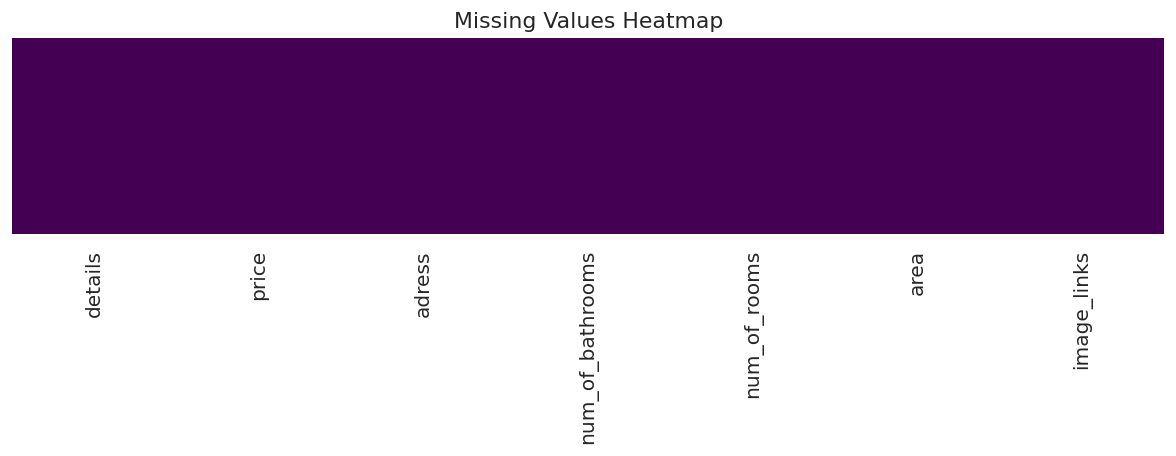

In [8]:
missing_pct = (df.isna().mean() * 100).round(2)
missing_summary = pd.DataFrame({'missing_count': missing, 'missing_%': missing_pct})
missing_summary = missing_summary[missing_summary['missing_count'] > 0].sort_values('missing_%', ascending=False)
print(missing_summary)

# Visualize
plt.figure(figsize=(10, 4))
sns.heatmap(df.isna(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.tight_layout()
plt.show()

In [9]:
'''
When the columns with > 50% missing, then it's better to drop entirely
But if numerical columns with <= 50% missing, then we impute with median (robust to outliers)
Categorical columns with <= 50% missing → impute with most frequent value
'''

# Drop columns with too many missing values
threshold = 0.50
cols_to_drop = missing_pct[missing_pct > threshold * 100].index.tolist()
if cols_to_drop:
    print(f'Dropping columns (>{int(threshold*100)}% missing): {cols_to_drop}')
    df.drop(columns=cols_to_drop, inplace=True)
else:
    print('No columns exceed the missing threshold.')

# Separate column types
var_quant = df.select_dtypes(exclude=['object', 'bool']).columns.tolist()
var_qual  = df.select_dtypes(include=['object', 'bool']).columns.tolist()

# Impute numerical columns with median
if var_quant:
    num_imputer = SimpleImputer(strategy='median')
    df[var_quant] = num_imputer.fit_transform(df[var_quant])
    print(f'Numerical columns imputed (median): {var_quant}')

# Impute categorical columns with most frequent value
if var_qual:
    cat_imputer = SimpleImputer(strategy='most_frequent')
    df[var_qual] = cat_imputer.fit_transform(df[var_qual])
    print(f'Categorical columns imputed (most frequent): {var_qual}')

print(f'\nMissing values remaining: {df.isna().sum().sum()}')

No columns exceed the missing threshold.
Numerical columns imputed (median): ['price', 'num_of_bathrooms', 'num_of_rooms', 'area']
Categorical columns imputed (most frequent): ['details', 'adress', 'image_links']

Missing values remaining: 0


## Dectect and remove outlier

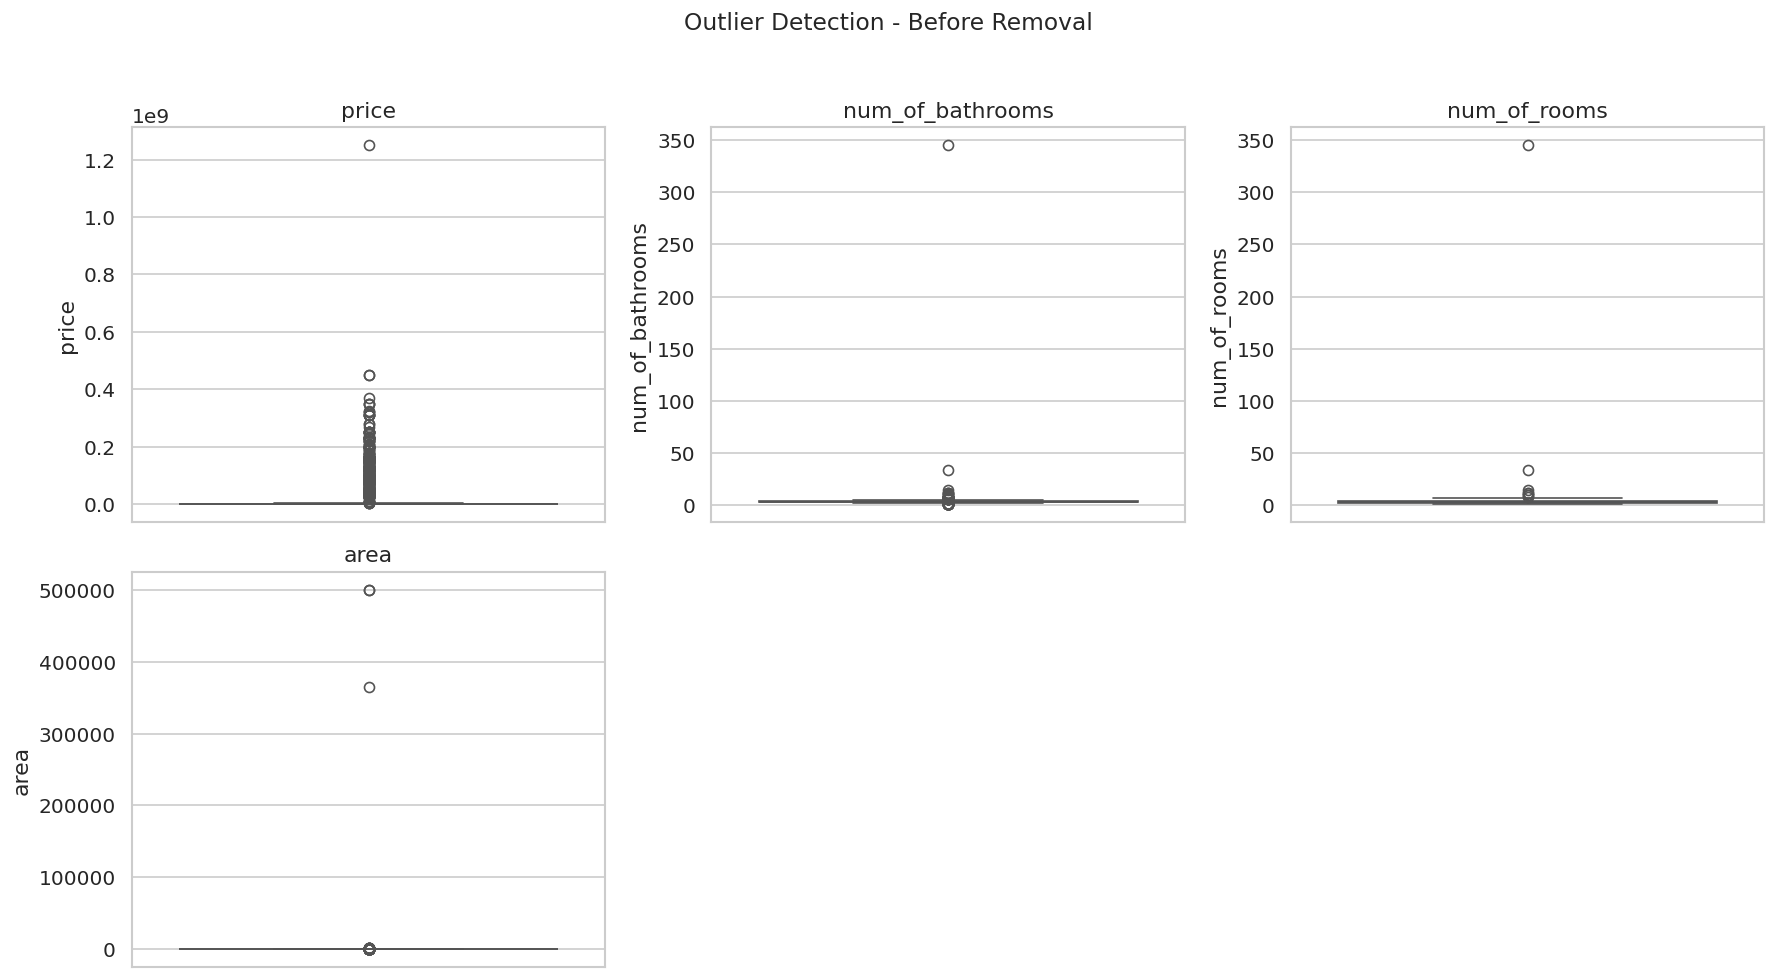

In [10]:
# visualize outliers with boxplots
if var_quant:
    n_cols = min(3, len(var_quant))
    n_rows = (len(var_quant)+ n_cols - 1)// n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize = (5*n_cols, 4*n_rows))
    axes = np.array(axes).flatten()
    for i, col in enumerate(var_quant):
        sns.boxplot(y=df[col], ax = axes[i])
        axes[i].set_title(col)
    for j in range(i +1, len(axes)):
        axes[j].set_visible(False)
    plt.suptitle('Outlier Detection - Before Removal', y=1.02, fontsize=14)
    plt.tight_layout()
    plt.show()

In [11]:
# Remove outliers using IQR method
# A row is considered an outlier if ANY numerical column falls outside
# [Q1 - 1.5*IQR, Q3 + 1.5*IQR]

def remove_outliers_iqr(dataframe, columns, factor=1.5):
    mask = pd.Series([True] * len(dataframe), index=dataframe.index)
    for col in columns:
        Q1 = dataframe[col].quantile(0.25)
        Q3 = dataframe[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - factor * IQR
        upper = Q3 + factor * IQR
        col_mask = dataframe[col].between(lower, upper)
        mask = mask & col_mask
    return dataframe[mask]

rows_before = len(df)
df = remove_outliers_iqr(df, var_quant)
df.reset_index(drop=True, inplace=True)
rows_after = len(df)

print(f'Rows before: {rows_before}')
print(f'Rows after : {rows_after}')
print(f'Outliers removed: {rows_before - rows_after} ({(rows_before - rows_after)/rows_before*100:.1f}%)')

Rows before: 1646
Rows after : 1194
Outliers removed: 452 (27.5%)


## Encode categorical variable

In [12]:
# Decide encoding strategy per column 
# Low cardinality (≤ 5 unique values) → One-Hot Encoding
# High cardinality (> 5 unique values) → Label Encoding
# Refresh var_qual after possible column drops
var_qual = df.select_dtypes(include = ['object','bool']).columns.tolist()

One_hot_encoding_cols = [c for c in var_qual if df[c].nunique()<=5]
label_cols = [c for c in var_qual if df[c].nunique()>5]
print(f'One-hot Encoding : {One_hot_encoding_cols}')
print(f'Label Encoding : {label_cols}')

One-hot Encoding : []
Label Encoding : ['details', 'adress', 'image_links']


In [13]:
# one hot encoding
if One_hot_encoding_cols:
    df = pd.get_dummies(df, columns = One_hot_encoding_cols, drop_first = True)
    print(f'One-Hot encoded colums : {One_hot_encoding_cols}')

# label encoding
label_encoding = LabelEncoder()
for col in label_cols:
    df[col]=label_encoding.fit_transform(df[col].astype(str))
    print(f'Label encoded : {col}')
print(f'\nDataframe shape after encoding : {df.shape}')
df.head()

Label encoded : details
Label encoded : adress
Label encoded : image_links

Dataframe shape after encoding : (1194, 7)


,details,price,adress,num_of_bathrooms,num_of_rooms,area,image_links
0,704,350000.0,3,3.0,3.0,200.0,725
1,75,300000.0,3,3.0,3.0,120.0,249
2,828,310000.0,3,3.0,3.0,120.0,1056
3,385,400000.0,3,3.0,3.0,130.0,339
4,189,200000.0,3,2.0,1.0,80.0,65


# Normalize /standardize numerical data

In [14]:
# Refresh numerical column list (now includes encoded booleans) 
# We apply StandardScaler to original continuous numerical columns only.
# (Encoded binary columns are already 0/1 — no need to scale them.)
var_quant = df.select_dtypes(include=[np.number]).columns.tolist()

# StandardScaler: zero mean, unit variance — best for models like SVM, PCA, linear regression
scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[var_quant] = scaler.fit_transform(df[var_quant])

print('StandardScaler applied to numerical columns.')
print(df_scaled[var_quant].describe().round(3))

StandardScaler applied to numerical columns.
        details     price    adress  num_of_bathrooms  num_of_rooms      area  \
count  1194.000  1194.000  1194.000          1194.000      1194.000  1194.000   
mean      0.000     0.000    -0.000             0.000         0.000    -0.000   
std       1.000     1.000     1.000             1.000         1.000     1.000   
min      -1.829    -1.549    -2.257            -1.936        -2.187    -2.320   
25%      -0.865    -0.739    -0.003            -0.603        -1.037    -0.673   
50%       0.087    -0.232    -0.003            -0.603         0.114    -0.007   
75%       0.837     0.478    -0.003             0.730         0.114     0.659   
max       1.650     4.129     3.754             2.063         2.414     2.656   

       image_links  
count     1194.000  
mean        -0.000  
std          1.000  
min         -1.731  
25%         -0.865  
50%          0.000  
75%          0.865  
max          1.731  


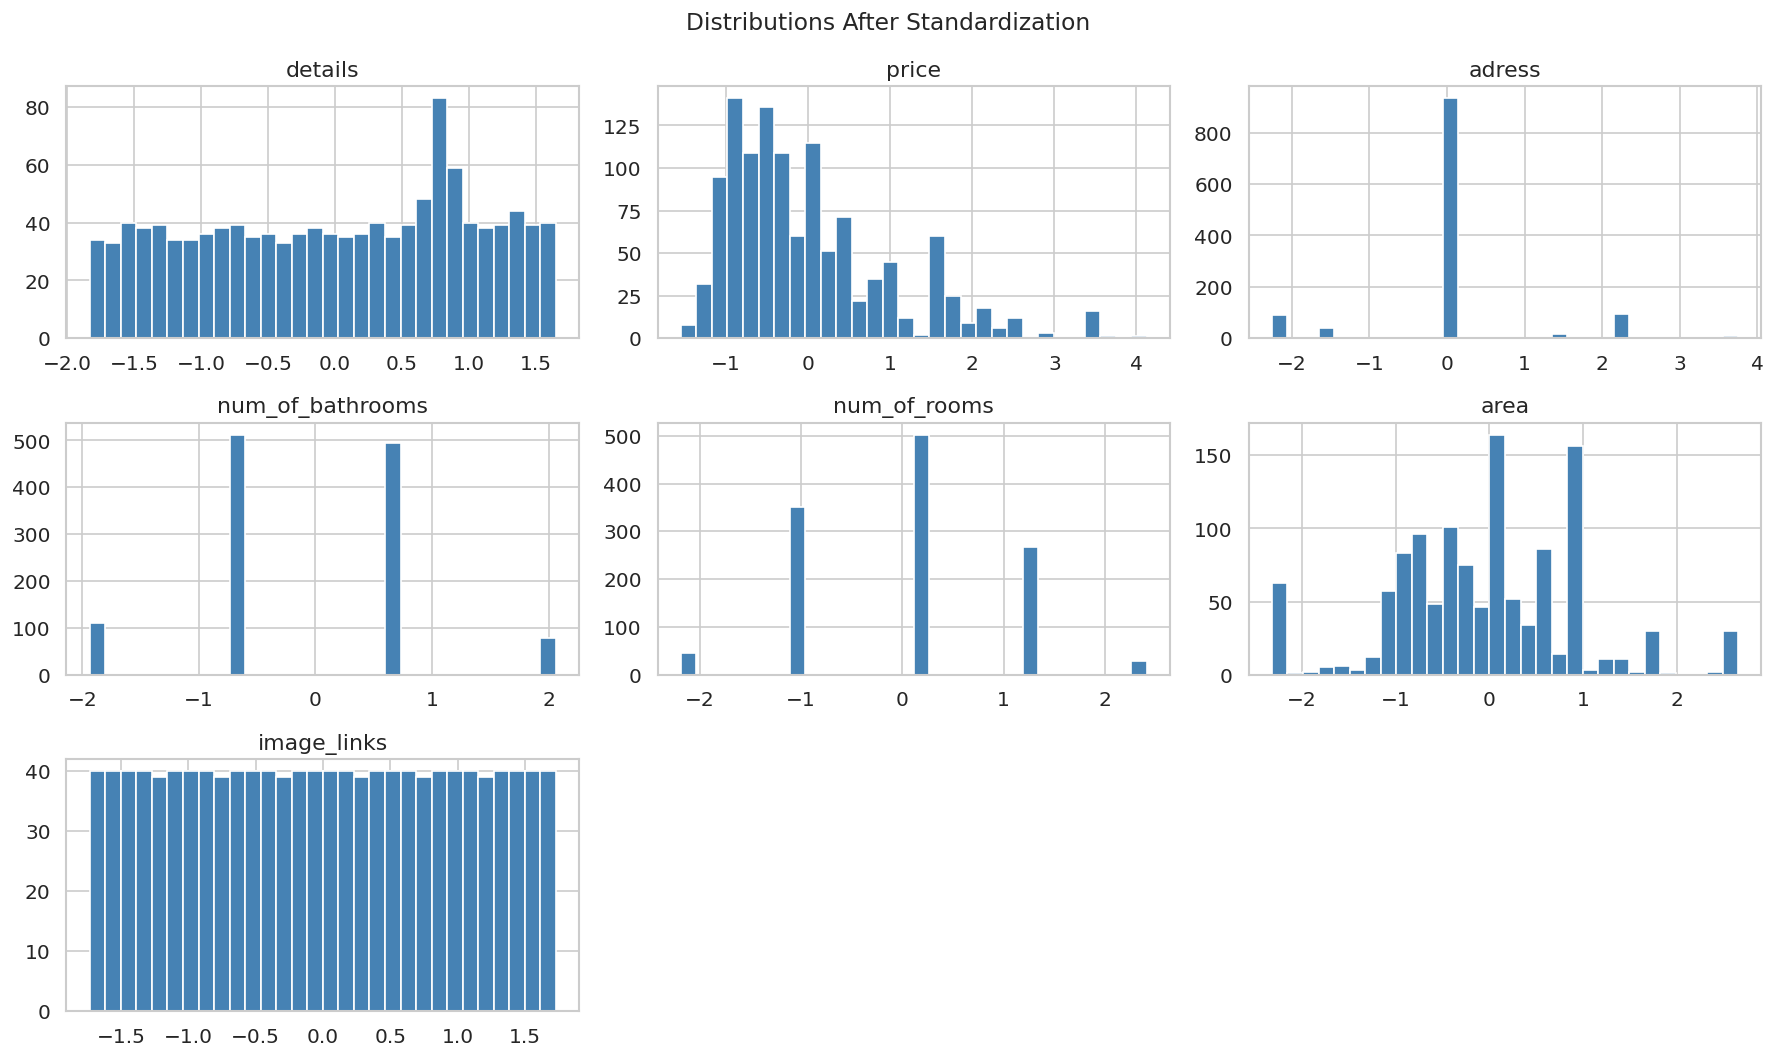

In [15]:
# Optional: MinMaxScaler (use instead if you need values in [0, 1])
# Uncomment to use MinMaxScaler instead:
#
# minmax = MinMaxScaler()
# df_scaled[var_quant] = minmax.fit_transform(df[var_quant])
# print('MinMaxScaler applied — values in [0, 1].')

# Distribution after scaling 
if var_quant:
    n_cols = min(3, len(var_quant))
    n_rows = (len(var_quant) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 3 * n_rows))
    axes = np.array(axes).flatten()
    for i, col in enumerate(var_quant):
        axes[i].hist(df_scaled[col], bins=30, color='steelblue', edgecolor='white')
        axes[i].set_title(col)
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    plt.suptitle('Distributions After Standardization', fontsize=14)
    plt.tight_layout()
    plt.show()

In [16]:
print('=' * 50)
print('PREPROCESSING COMPLETE')
print('=' * 50)
print(f'Final shape          : {df_scaled.shape}')
print(f'Missing values left  : {df_scaled.isna().sum().sum()}')
print(f'Numerical columns    : {len(var_quant)}')
print(f'All dtypes numeric   : {all(df_scaled.dtypes != object)}')
print()
df_scaled.head()

PREPROCESSING COMPLETE
Final shape          : (1194, 7)
Missing values left  : 0
Numerical columns    : 7
All dtypes numeric   : True



,details,price,adress,num_of_bathrooms,num_of_rooms,area,image_links
0,0.612496,-0.840245,-0.003146,-0.602946,0.113683,0.991470,0.372812
1,-1.569183,-0.941651,-0.003146,-0.602946,0.113683,-0.339800,-1.008187
2,1.042589,-0.921370,-0.003146,-0.602946,0.113683,-0.339800,1.333128
3,-0.493952,-0.738838,-0.003146,-0.602946,0.113683,-0.173391,-0.747074
4,-1.173775,-1.144465,-0.003146,-1.936127,-2.186951,-1.005435,-1.542019


# Exploratory_Data_Analysis

In [17]:
# NOTE: This cell rebuilds df_scaled from scratch so the EDA section
# can run standalone after the preprocessing section above.
# If you are running the full notebook top-to-bottom, df_scaled already
# exists — this cell is harmless (it just re-runs the pipeline).

# reload & preprocess (mirrors the preprocessing section) 
df_raw = pd.read_csv('/kaggle/input/datasets/jharilova/data-clean/data_clean.csv')
df = df_raw.copy()

# drop high-missing columns
missing_pct = df.isna().mean() * 100
df.drop(columns=missing_pct[missing_pct > 50].index.tolist(), inplace=True)

var_quant = df.select_dtypes(exclude=['object', 'bool']).columns.tolist()
var_qual  = df.select_dtypes(include=['object', 'bool']).columns.tolist()

if var_quant:
    df[var_quant] = SimpleImputer(strategy='median').fit_transform(df[var_quant])
if var_qual:
    df[var_qual]  = SimpleImputer(strategy='most_frequent').fit_transform(df[var_qual])

# remove IQR outliers
def remove_outliers_iqr(dataframe, columns, factor=1.5):
    mask = pd.Series(True, index=dataframe.index)
    for col in columns:
        Q1, Q3 = dataframe[col].quantile([0.25, 0.75])
        IQR = Q3 - Q1
        mask &= dataframe[col].between(Q1 - factor*IQR, Q3 + factor*IQR)
    return dataframe[mask]

df = remove_outliers_iqr(df, var_quant).reset_index(drop=True)

# encode
var_qual = df.select_dtypes(include=['object', 'bool']).columns.tolist()
ohe_cols   = [c for c in var_qual if df[c].nunique() <= 5]
label_cols = [c for c in var_qual if df[c].nunique() >  5]
if ohe_cols:
    df = pd.get_dummies(df, columns=ohe_cols, drop_first=True)
le = LabelEncoder()
for col in label_cols:
    df[col] = le.fit_transform(df[col].astype(str))

# scale
var_quant = df.select_dtypes(include=[np.number]).columns.tolist()
scaler    = StandardScaler()
df_scaled = df.copy()
df_scaled[var_quant] = scaler.fit_transform(df[var_quant])

print(f'df_scaled ready — shape: {df_scaled.shape}')
df_scaled.head()


df_scaled ready — shape: (1194, 7)


,details,price,adress,num_of_bathrooms,num_of_rooms,area,image_links
0,0.612496,-0.840245,-0.003146,-0.602946,0.113683,0.991470,0.372812
1,-1.569183,-0.941651,-0.003146,-0.602946,0.113683,-0.339800,-1.008187
2,1.042589,-0.921370,-0.003146,-0.602946,0.113683,-0.339800,1.333128
3,-0.493952,-0.738838,-0.003146,-0.602946,0.113683,-0.173391,-0.747074
4,-1.173775,-1.144465,-0.003146,-1.936127,-2.186951,-1.005435,-1.542019


# Summary statistic

In [18]:
# Central tendency & dispersion
summary = df_scaled[var_quant].agg(['mean', 'median', 'std', 'var',
                                     'min', 'max',
                                     lambda x: x.quantile(0.25),
                                     lambda x: x.quantile(0.75),
                                     'skew', 'kurt'])
summary.index = ['mean', 'median', 'std', 'variance',
                 'min', 'max', 'Q1 (25%)', 'Q3 (75%)',
                 'skewness', 'kurtosis']

print('=' * 60)
print('SUMMARY STATISTICS  (standardised values)')
print('=' * 60)
summary.round(4)


SUMMARY STATISTICS  (standardised values)


,details,price,adress,num_of_bathrooms,num_of_rooms,area,image_links
mean,0.0000,0.0000,-0.0000,0.0000,0.0000,-0.0000,-0.0000
median,0.0870,-0.2318,-0.0031,-0.6029,0.1137,-0.0070,0.0000
std,1.0004,1.0004,1.0004,1.0004,1.0004,1.0004,1.0004
variance,1.0008,1.0008,1.0008,1.0008,1.0008,1.0008,1.0008
min,-1.8293,-1.5494,-2.2572,-1.9361,-2.1870,-2.3201,-1.7306
max,1.6496,4.1287,3.7537,2.0634,2.4143,2.6556,1.7306
Q1 (25%),-0.8651,-0.7388,-0.0031,-0.6029,-1.0366,-0.6726,-0.8653
Q3 (75%),0.8371,0.4780,-0.0031,0.7302,0.1137,0.6587,0.8653
skewness,-0.1584,1.2333,0.3423,-0.0276,0.0545,0.0070,0.0000
kurtosis,-1.2098,1.4181,2.6565,-0.3433,-0.4071,0.6080,-1.2000


In [19]:
# Range & IQR for each numerical feature 
range_iqr = pd.DataFrame({
    'range':   df_scaled[var_quant].max() - df_scaled[var_quant].min(),
    'IQR':     df_scaled[var_quant].quantile(0.75) - df_scaled[var_quant].quantile(0.25),
    'CV (%)':  (df_scaled[var_quant].std() / df_scaled[var_quant].mean().abs().replace(0, np.nan) * 100).round(2)
})
print('Range / IQR / Coefficient of Variation per feature')
range_iqr.sort_values('IQR', ascending=False)


Range / IQR / Coefficient of Variation per feature


,range,IQR,CV (%)
image_links,3.461202,1.730601,8.405549e+18
details,3.478893,1.702160,5.253468e+17
num_of_bathrooms,3.999542,1.333181,1.256904e+18
area,4.975620,1.331270,4.202774e+18
price,5.678068,1.216881,1.159386e+18
num_of_rooms,4.601267,1.150317,5.698677e+17
adress,6.010895,0.000000,5.336856e+17


In [20]:
# Class balance for categorical / boolean columns (original df) 
bool_cols = [c for c in df_scaled.columns if df_scaled[c].nunique() == 2]
if bool_cols:
    print('Binary / boolean column value counts (% of total rows):')
    for col in bool_cols:
        vc = df_scaled[col].value_counts(normalize=True).mul(100).round(1)
        print(f'  {col}: {vc.to_dict()}')
else:
    print('No binary columns found.')


No binary columns found.


# Distrubititions histograms

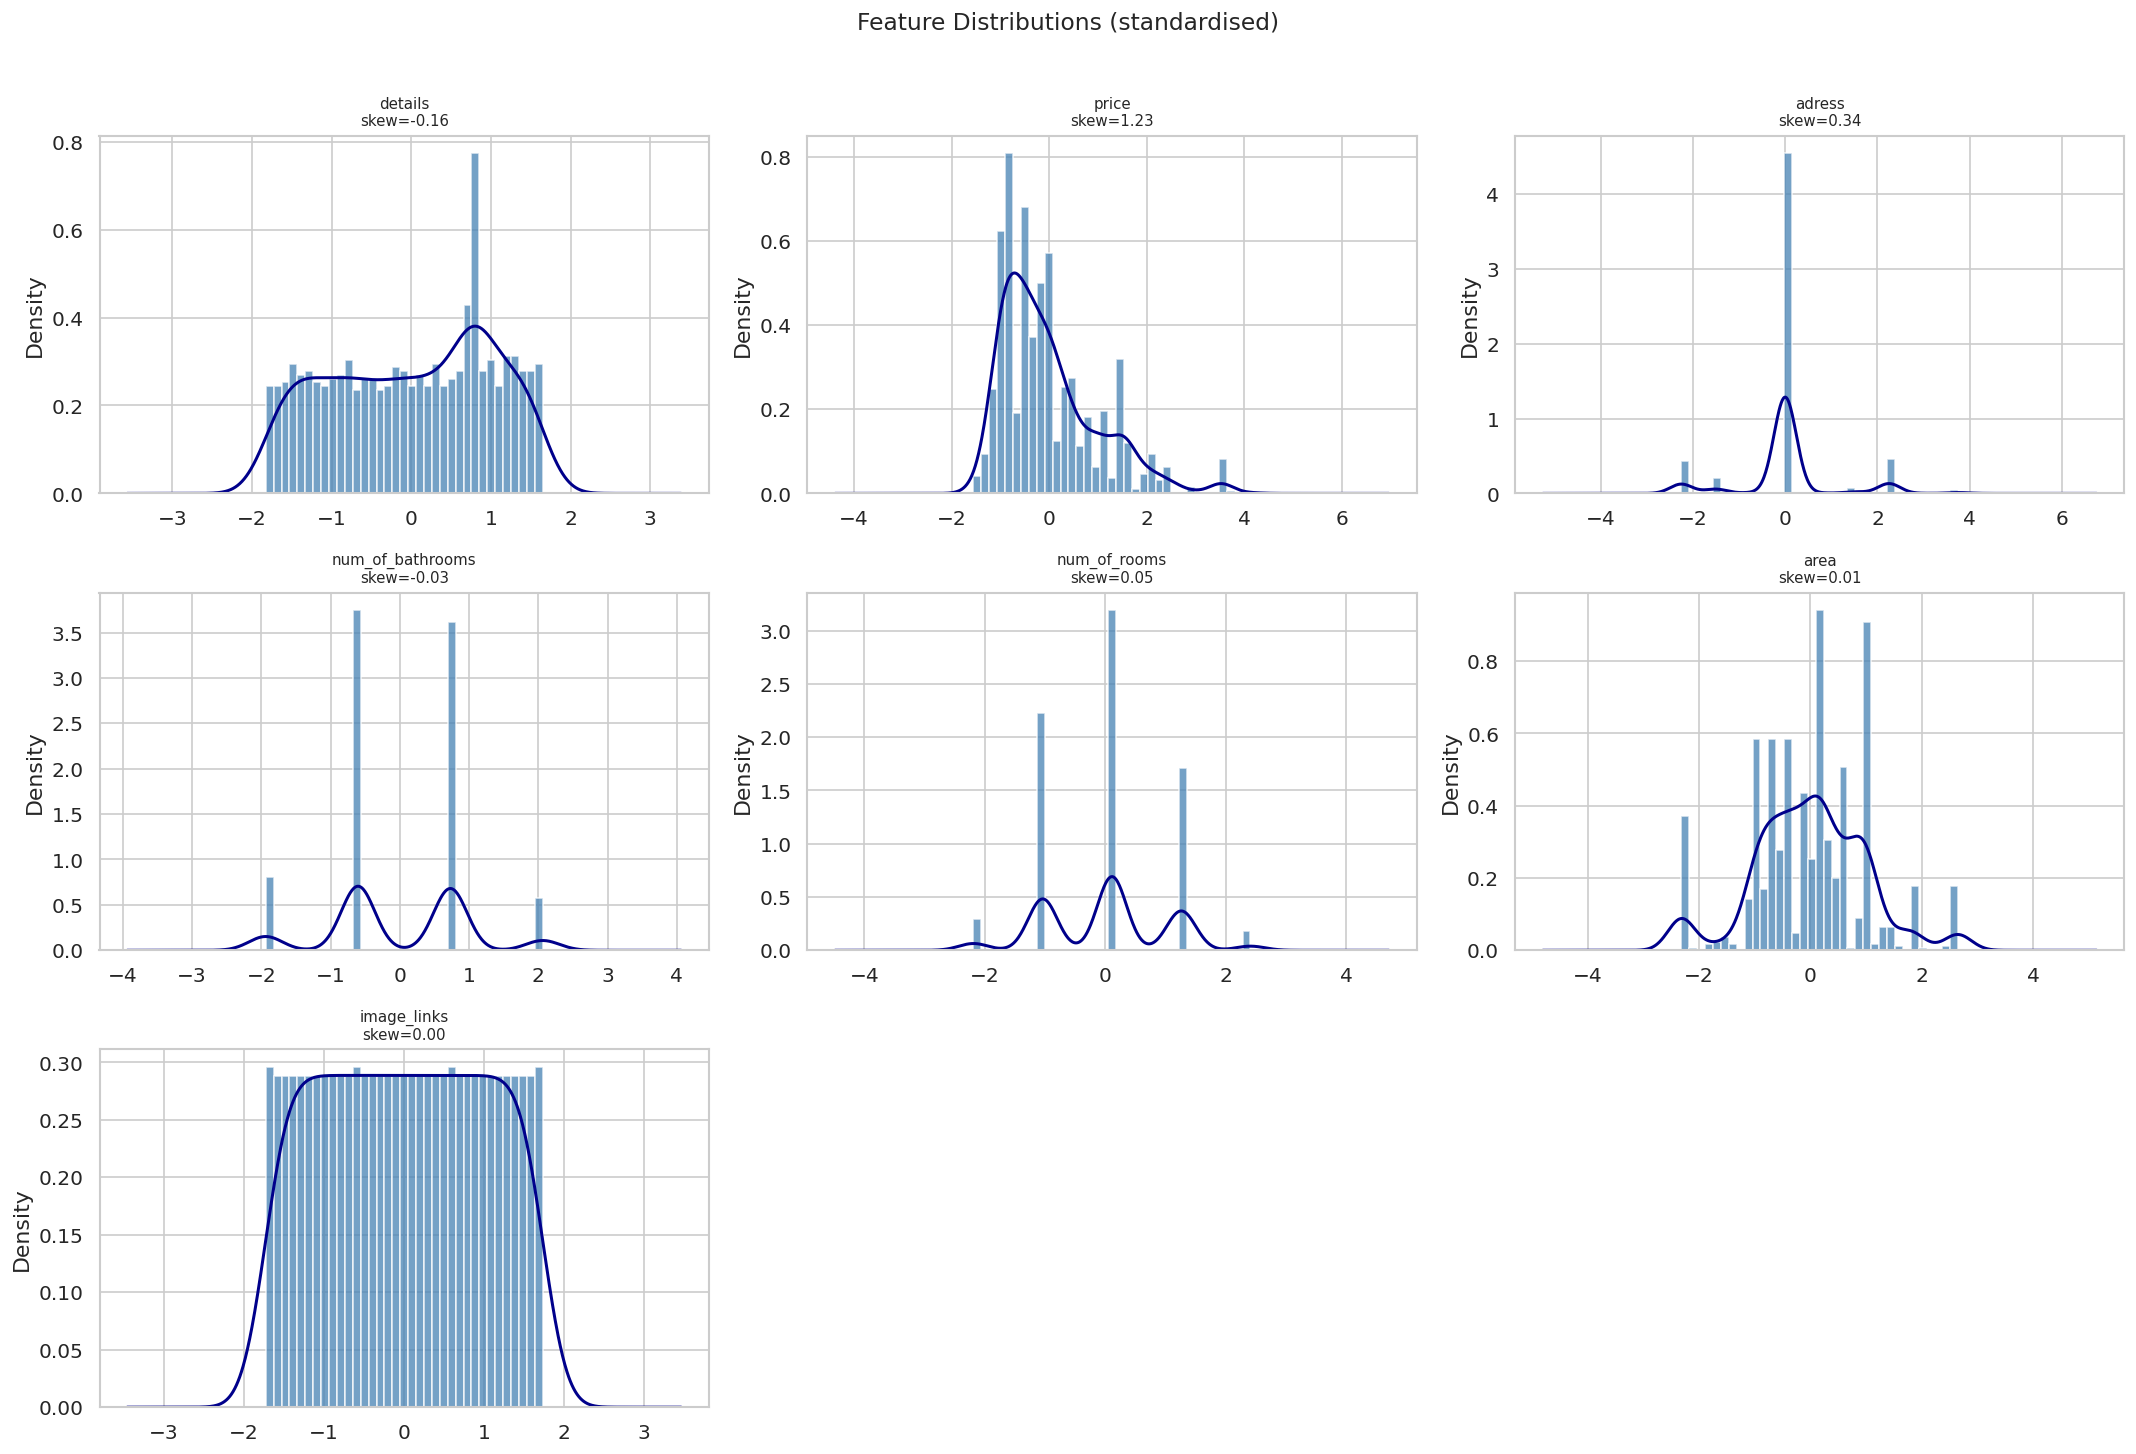

Saved: histograms.png


In [21]:
n_cols = min(3, len(var_quant))
n_rows = (len(var_quant) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 4*n_rows))
axes = np.array(axes).flatten()

for i, col in enumerate(var_quant):
    ax = axes[i]
    # histogram + KDE
    ax.hist(df_scaled[col], bins=35, color='steelblue',
            edgecolor='white', alpha=0.75, density=True)
    df_scaled[col].plot.kde(ax=ax, color='darkblue', linewidth=1.8)
    # skewness annotation
    skew = df_scaled[col].skew()
    ax.set_title(f'{col}\nskew={skew:.2f}', fontsize=9)
    ax.set_xlabel('')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Feature Distributions (standardised)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('histograms.png', bbox_inches='tight')
plt.show()
print('Saved: histograms.png')


# spread and outlier boxplot

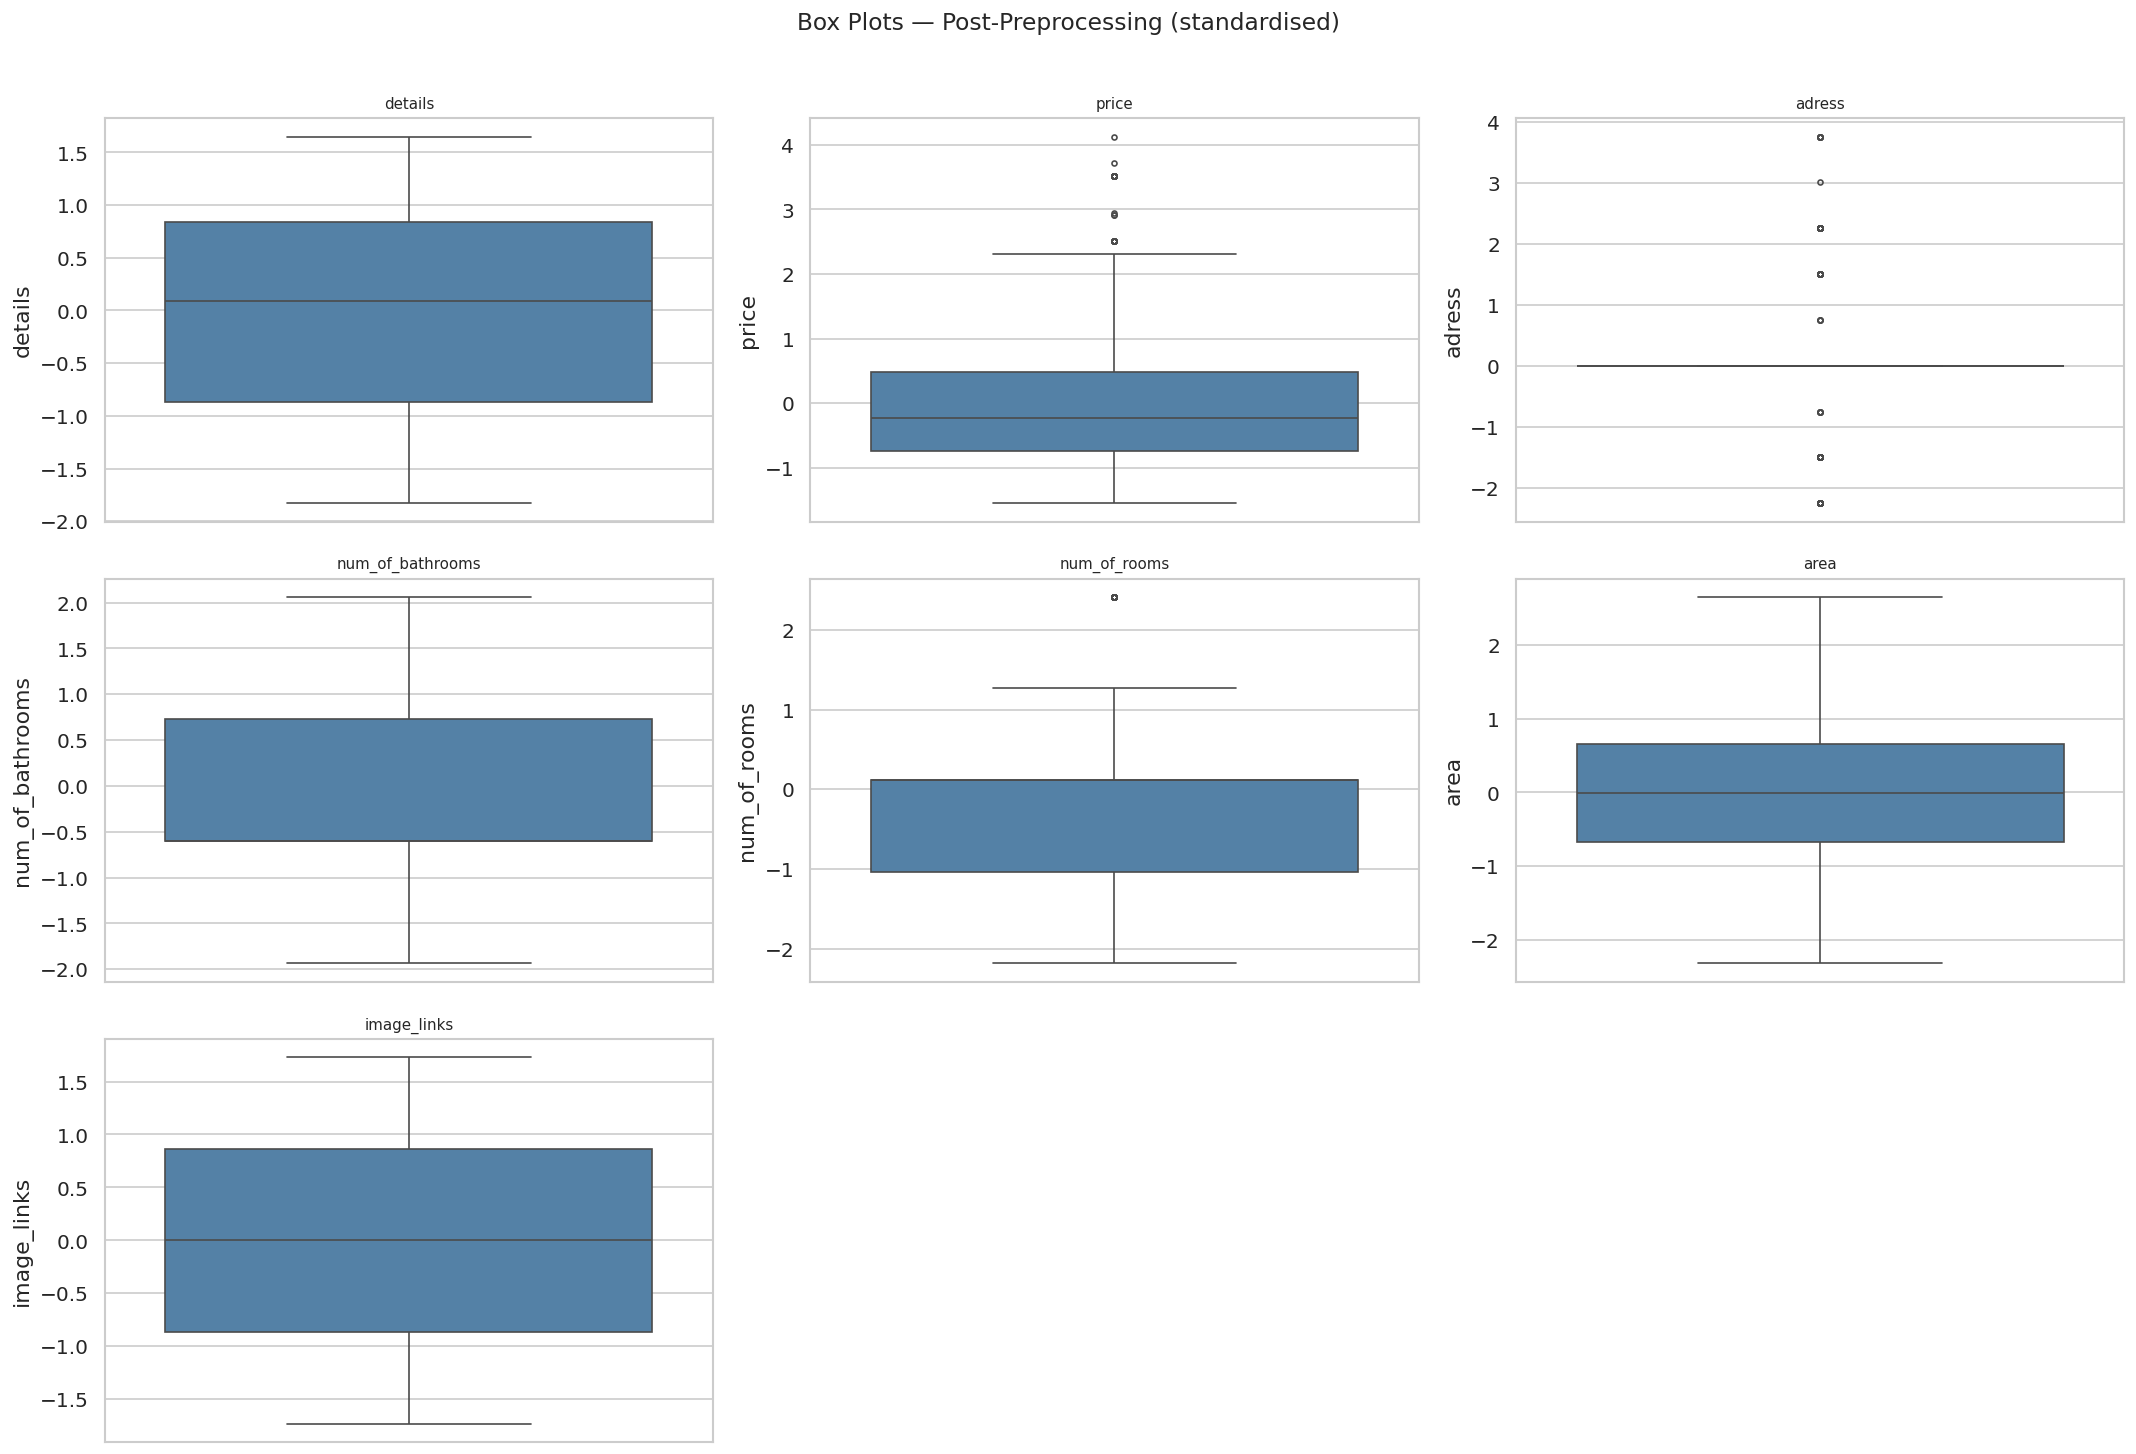

Saved: boxplots.png


In [22]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 4*n_rows))
axes = np.array(axes).flatten()

for i, col in enumerate(var_quant):
    ax = axes[i]
    sns.boxplot(y=df_scaled[col], ax=ax,
                color='steelblue', flierprops=dict(marker='o', markersize=3,
                                                    linestyle='none', color='crimson'))
    ax.set_title(col, fontsize=9)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Box Plots — Post-Preprocessing (standardised)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('boxplots.png', bbox_inches='tight')
plt.show()
print('Saved: boxplots.png')


# Pairwise Relationships _ scatter plots

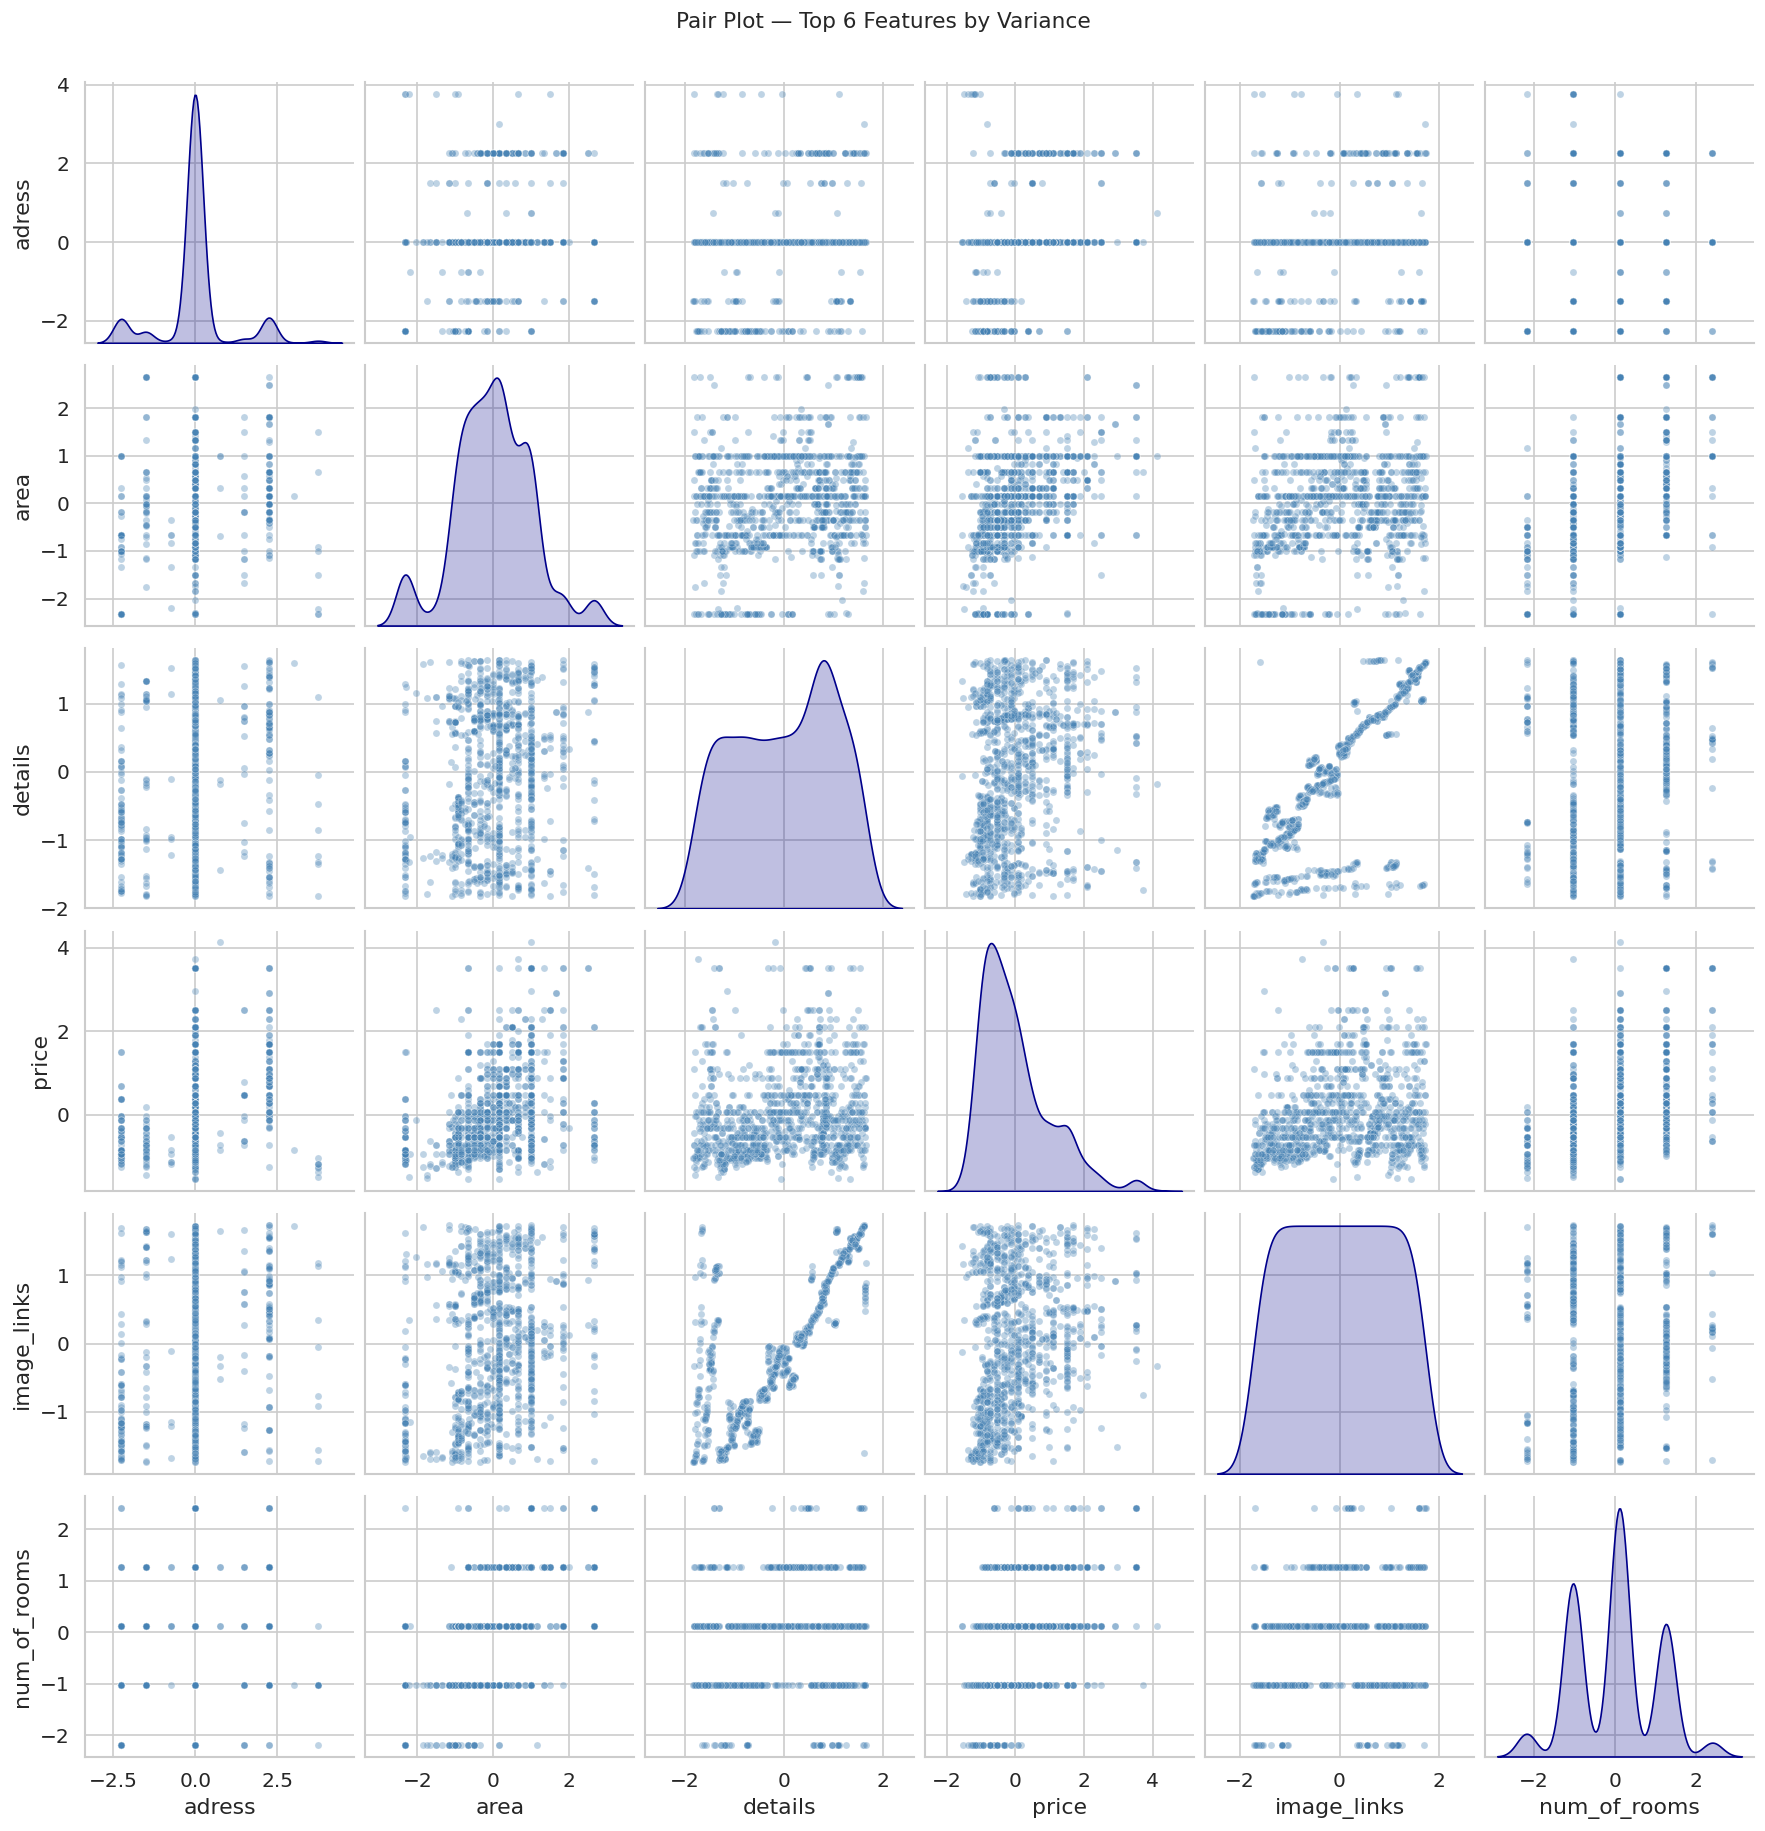

Saved: scatter_pairplot.png


In [23]:
# Limit pair-plot to the top-6 numerical features (by variance) for readability
top_features = (df_scaled[var_quant]
                .var()
                .nlargest(min(6, len(var_quant)))
                .index
                .tolist())

pair_grid = sns.pairplot(df_scaled[top_features],
                          plot_kws=dict(alpha=0.35, s=18, color='steelblue'),
                          diag_kind='kde',
                          diag_kws=dict(color='darkblue', fill=True))

pair_grid.figure.suptitle(
    f'Pair Plot — Top {len(top_features)} Features by Variance',
    y=1.02, fontsize=13)
pair_grid.figure.savefig('scatter_pairplot.png', bbox_inches='tight')
plt.show()
print('Saved: scatter_pairplot.png')


# Correlation matrix

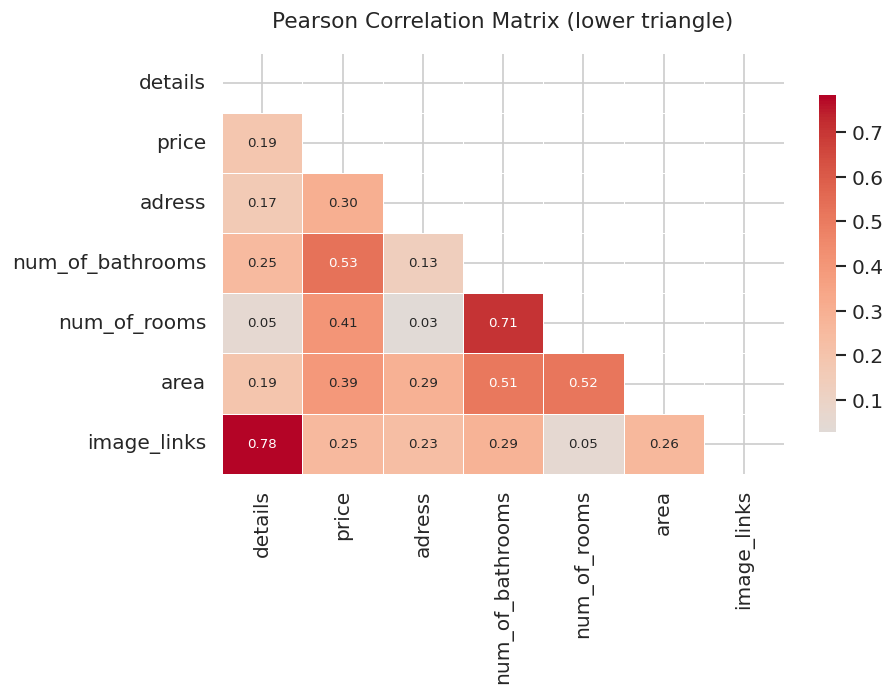

Saved: correlation_matrix.png


In [24]:
corr = df_scaled[var_quant].corr()

fig, ax = plt.subplots(figsize=(max(8, len(var_quant)), max(6, len(var_quant)-1)))
mask = np.triu(np.ones_like(corr, dtype=bool))          # hide upper triangle

sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5,
            annot_kws={'size': 8}, ax=ax,
            cbar_kws={'shrink': 0.8})

ax.set_title('Pearson Correlation Matrix (lower triangle)', fontsize=13, pad=15)
plt.tight_layout()
plt.savefig('correlation_matrix.png', bbox_inches='tight')
plt.show()
print('Saved: correlation_matrix.png')


In [25]:
# Top correlated pairs (|r| > 0.5) 
corr_pairs = (corr.where(np.tril(np.ones(corr.shape), k=-1).astype(bool))
              .stack()
              .reset_index())
corr_pairs.columns = ['Feature A', 'Feature B', 'Pearson r']
corr_pairs['|r|'] = corr_pairs['Pearson r'].abs()

strong = corr_pairs[corr_pairs['|r|'] > 0.5].sort_values('|r|', ascending=False)
print(f'Strong correlations (|r| > 0.5): {len(strong)} pairs')
strong.to_string(index=False)
strong


Strong correlations (|r| > 0.5): 5 pairs


,Feature A,Feature B,Pearson r,|r|
15,image_links,details,0.784170,0.784170
9,num_of_rooms,num_of_bathrooms,0.709463,0.709463
4,num_of_bathrooms,price,0.531592,0.531592
14,area,num_of_rooms,0.520553,0.520553
13,area,num_of_bathrooms,0.512648,0.512648


# EDA Report

In [26]:
# ── Programmatically generate the report ────────────────────────────────────
lines = []
lines.append('=' * 65)
lines.append('  EXPLORATORY DATA ANALYSIS — SUMMARY REPORT')
lines.append('=' * 65)

lines.append(f'\n▶ Dataset shape (after preprocessing): {df_scaled.shape[0]} rows × {df_scaled.shape[1]} columns')
lines.append(f'▶ Numerical features analysed        : {len(var_quant)}')

# Skewness
skews = df_scaled[var_quant].skew().sort_values()
highly_skewed = skews[skews.abs() > 1]
lines.append(f'\n── Skewness ──────────────────────────────────────────────')
if highly_skewed.empty:
    lines.append('  All features are approximately symmetric (|skew| ≤ 1).')
else:
    lines.append(f'  Highly skewed features (|skew| > 1): {len(highly_skewed)}')
    for feat, sk in highly_skewed.items():
        direction = 'right-skewed (+)' if sk > 0 else 'left-skewed (−)'
        lines.append(f'    • {feat}: {sk:.3f}  → {direction}')

# Spread
lines.append(f'\n── Spread (IQR, post-standardisation) ───────────────────')
iqr_vals = df_scaled[var_quant].quantile(0.75) - df_scaled[var_quant].quantile(0.25)
widest  = iqr_vals.nlargest(3)
narrowest = iqr_vals.nsmallest(3)
lines.append('  Widest IQR (most spread):')
for f, v in widest.items():
    lines.append(f'    • {f}: {v:.3f}')
lines.append('  Narrowest IQR (most concentrated):')
for f, v in narrowest.items():
    lines.append(f'    • {f}: {v:.3f}')

# Correlations
lines.append(f'\n── Correlations ──────────────────────────────────────────')
if strong.empty:
    lines.append('  No strong pairwise correlations (|r| > 0.5) detected.')
else:
    lines.append(f'  {len(strong)} strongly correlated pair(s):')
    for _, row in strong.head(10).iterrows():
        direction = 'positive' if row['Pearson r'] > 0 else 'negative'
        lines.append(f'    • {row["Feature A"]} ↔ {row["Feature B"]}: '
                     f'r = {row["Pearson r"]:.3f}  ({direction})')

# Distributions
normal_like = skews[skews.abs() <= 0.5]
lines.append(f'\n── Distribution Summary ──────────────────────────────────')
lines.append(f'  Approx. normally distributed features (|skew| ≤ 0.5): {len(normal_like)}')
lines.append(f'  Moderately skewed (0.5 < |skew| ≤ 1)               : {len(skews[(skews.abs()>0.5)&(skews.abs()<=1)])}')
lines.append(f'  Highly skewed (|skew| > 1)                          : {len(highly_skewed)}')

lines.append(f'\n── Visualisations saved ──────────────────────────────────')
for f in ['histograms.png', 'boxplots.png', 'scatter_pairplot.png', 'correlation_matrix.png']:
    lines.append(f'  ✓ {f}')

lines.append('\n' + '=' * 65)
lines.append('  END OF REPORT')
lines.append('=' * 65)

report_text = '\n'.join(lines)
print(report_text)

# Save to file
with open('eda_report.txt', 'w') as fh:
    fh.write(report_text)
print('\nReport saved → eda_report.txt')


  EXPLORATORY DATA ANALYSIS — SUMMARY REPORT

▶ Dataset shape (after preprocessing): 1194 rows × 7 columns
▶ Numerical features analysed        : 7

── Skewness ──────────────────────────────────────────────
  Highly skewed features (|skew| > 1): 1
    • price: 1.233  → right-skewed (+)

── Spread (IQR, post-standardisation) ───────────────────
  Widest IQR (most spread):
    • image_links: 1.731
    • details: 1.702
    • num_of_bathrooms: 1.333
  Narrowest IQR (most concentrated):
    • adress: 0.000
    • num_of_rooms: 1.150
    • price: 1.217

── Correlations ──────────────────────────────────────────
  5 strongly correlated pair(s):
    • image_links ↔ details: r = 0.784  (positive)
    • num_of_rooms ↔ num_of_bathrooms: r = 0.709  (positive)
    • num_of_bathrooms ↔ price: r = 0.532  (positive)
    • area ↔ num_of_rooms: r = 0.521  (positive)
    • area ↔ num_of_bathrooms: r = 0.513  (positive)

── Distribution Summary ──────────────────────────────────
  Approx. normally distrib